In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
import matplotlib.patheffects as PathEffects
import numpy as np
import shoji
from typing import List, Optional
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import scipy as sci
import scanpy as sc
from scipy.stats import ks_2samp, mannwhitneyu, ttest_ind

In [2]:
#Save h5ad file from url: https://storage.googleapis.com/linnarsson-lab-glioblastoma/woundresponse/bulk_samples_GBO_control_smartseq_2025.h5ad
#Alternatively follow the instructions at https://github.com/linnarsson-lab/shoji/blob/master/notebooks/GettingStarted_Shoji.ipynb under "Download example dataset" to create a temporary directory for the file.

In [3]:
# Load the sample data into your local Shoji database
GBO = sc.read_h5ad('/home/jesper/data/bulk_samples_GBO_control_smartseq_2025.h5ad') #Change to the path where the h5ad file has been saved 

In [4]:
GBO.obs

,Barcode,BarcodeIdx,Celltype,Condition,ID,Pool,Sample,Time,Time_Sample,TotalMTCounts,TotalReadGenes,TotalReads,TotalUMIGenes,TotalUMIs,obs_names
0,-,0,GBO,-P-H,A01,20250915,SL007,0h,0h_SL007,736052,20750,19129730,20750,19129730,A01
1,-,1,GBO,-P-H,A10,20250915,SL013,72h,72h_SL013,1064583,21520,19263749,21520,19263749,A10
2,-,2,GBO,-P-H,A11,20250915,SL014,72h,72h_SL014,544076,19977,16495182,19977,16495182,A11
3,-,3,GBO,-P-H,A12,20250915,SL027A,72h,72h_SL027A,495789,20620,17580279,20620,17580279,A12
4,-,4,GBO,-P-H,A02,20250915,SL013,0h,0h_SL013,911511,20911,16290418,20911,16290418,A02
5,-,5,GBO,-P-H,A03,20250915,SL014,0h,0h_SL014,471872,19995,15414781,19995,15414781,A03
6,-,6,GBO,-P-H,A04,20250915,SL027A,0h,0h_SL027A,730808,21165,18691567,21165,18691567,A04
7,-,7,GBO,-P-H,A05,20250915,SL007,24h,24h_SL007,662777,21013,16066657,21013,16066657,A05
8,-,8,GBO,-P-H,A06,20250915,SL013,24h,24h_SL013,597284,21703,17245946,21703,17245946,A06
9,-,9,GBO,-P-H,A07,20250915,SL014,24h,24h_SL014,480989,21013,17962416,21013,17962416,A07


## Figure 2b

### Full list of MES1 and MES2 genes

In [5]:
MES1 = np.array(["CHI3L1","ANXA2","ANXA1","CD44","VIM","MT2A","C1S","NAMPT","EFEMP1","C1R","SOD2","IFITM3","TIMP1","SPP1","A2M","S100A11","MT1X","S100A10","FN1","LGALS1","S100A16","CLIC1","MGST1","RCAN1","TAGLN2","NPC2","SERPING1","TCIM","EMP1","APOE","CTSB","C3","LGALS3","MT1E","EMP3","SERPINA3","ACTN1","PRDX6","IGFBP7","SERPINE1","PLP2","MGP","CLIC4","GFPT2","GSN","NNMT","TUBA1C","GJA1","TNFRSF1A","WWTR1"])
MES2 = np.array(["HILPDA","ADM","DDIT3","NDRG1","HERPUD1","DNAJB9","TRIB3","ENO2","AKAP12","SQSTM1","MT1X","ATF3","NAMPT","NRN1","SLC2A1","BNIP3","LGALS3","INSIG2","IGFBP3","PPP1R15A","VIM","PLOD2","GBE1","SLC2A3","FTL","WARS1","ERO1A","XPOT","HSPA5","GDF15","ANXA2","EPAS1","LDHA","P4HA1","SERTAD1","PFKP","PGK1","EGLN3","SLC6A6","CA9","BNIP3L","RPL21","TRAM1","UFM1","ASNS","GOLT1B","ANGPTL4","SLC39A14","CDKN1A","HSPA9"])
gene_list = np.concatenate((MES1, MES2))
_, i = np.unique(gene_list, return_index=True)
gene_list = gene_list[np.sort(i)]

### Calculate fraction of total UMIs originating from the MES-genes

In [6]:
df = GBO.to_df(layer=None) #Save as dataframe
df_all = df.sum(axis=1) #total UMIs per sample
MES_df = df[gene_list] # MES-genes dataframe
df_mes = MES_df.sum(axis=1) #total UMIs MES genes per sample
zero = GBO[GBO.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_mes = df_mes[zero.obs.index]
one = GBO[GBO.obs["Time"] == "24h"]
one_all = df_all[one.obs.index]
one_mes = df_mes[one.obs.index]
three = GBO[GBO.obs["Time"] == "72h"]
three_all = df_all[three.obs.index]
three_mes = df_mes[three.obs.index]
six = GBO[GBO.obs["Time"] == "144h"]
six_all = df_all[six.obs.index]
six_mes = df_mes[six.obs.index]
#Fraction of MES-genes UMIs of total per timepoint 
MES_zero = zero_mes/zero_all
MES_one = one_mes/one_all
MES_three = three_mes/three_all
MES_six = six_mes/six_all
#Make a dataframe with timepoint as columns
merged = pd.concat([MES_zero, MES_one, MES_three, MES_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(GBO.obs.Time_Sample)
merged1 = merged.rename(index=rename) #rename index 
merged1 = merged1.multiply(100) #multiply by 100 (display percent)
rename = dict(GBO.obs.Sample)
merg = merged.rename(index=rename)
merg = merg.mean(level=0) #condense df by merging rows (mean) of same sample+condition but different time points
merg = merg.multiply(100)
merg1 = merg.mean(axis=0) #condense df by merging all samples of same condition but different time points (columns) 
merg

,0,24,72,144
SL007,2.822486,2.513223,1.856766,2.637098
SL013,3.559915,1.966555,1.662709,1.683068
SL014,8.099460,4.573310,4.142731,3.600167
SL027A,4.266886,2.664684,3.198863,3.068915


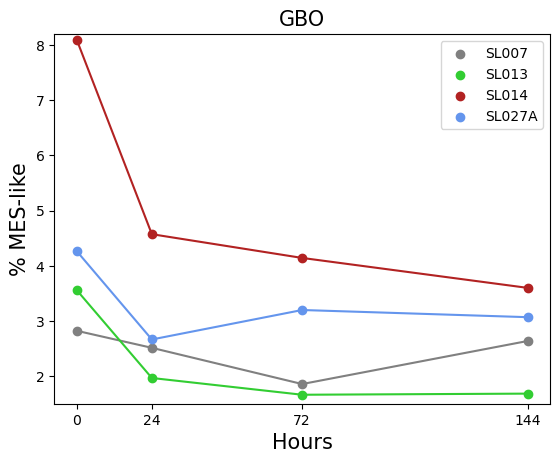

In [7]:
#Plot data as separate scatterplots
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='grey')
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='limegreen')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='firebrick')
plt.scatter(numb, merg.iloc[3],label=(merg.index[3]), color='cornflowerblue')
plt.plot(numb, merg.iloc[0], color='grey')
plt.plot(numb, merg.iloc[1], color='limegreen')
plt.plot(numb, merg.iloc[2], color='firebrick')
plt.plot(numb, merg.iloc[3], color='cornflowerblue')
plt.ylim(1.5, 8.2)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% MES-like', fontsize=15)
plt.title('GBO', fontsize=15)
plt.xticks(numb)
plt.show()

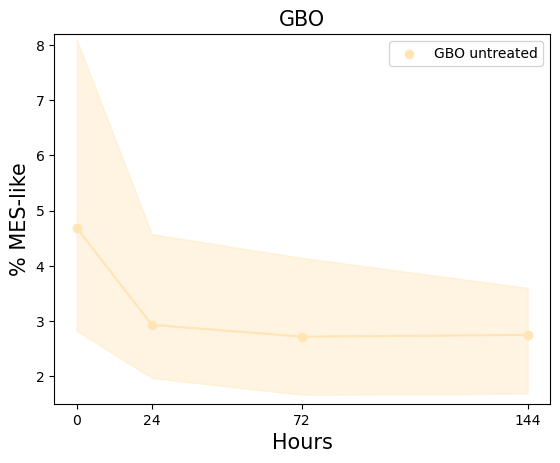

In [8]:
numb = merg1.index.astype(int)
plt.scatter(numb, merg1,label='GBO untreated', color='moccasin')
plt.plot(numb, merg1, color='moccasin')
plt.fill_between(numb, np.min(merg[0:3]),np.max(merg[0:3]), color='moccasin', alpha=0.4) #fill/shaded region instead of whiskers
plt.ylim(1.5, 8.2)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% MES-like', fontsize=15)
plt.title('GBO', fontsize=15)
plt.xticks(numb)
None

### Statistics

In [9]:
#One-sided
#+p-h 0 vs 24 hours
mannwhitneyu(merg[0:4]['0'], merg[0:4]['24'], alternative='greater') #not significant

MannwhitneyuResult(statistic=13.0, pvalue=0.1)

In [10]:
#One-sided
#+p-h 0 vs 72 hours
mannwhitneyu(merg[0:4]['0'], merg[0:4]['72'], alternative='greater') #not significant

MannwhitneyuResult(statistic=13.0, pvalue=0.1)

### Full list other neftel-states

In [11]:
AC = np.array(["CST3","S100B","SLC1A3","HEPN1","HOPX","MT3","SPARCL1","MLC1","GFAP","FABP7","BCAN","PON2","METTL7B","SPARC","GATM","RAMP1","PMP2","AQP4","DBI","EDNRB","PTPRZ1","CLU","PMP22","ATP1A2","S100A16","HEY1","PCDHGC3","TTYH1","NDRG2","PRCP","ATP1B2","AGT","PLTP","GPM6B","F3","RAB31","PLPP3","ANXA5","TSPAN7"])
OPC = np.array(["BCAN","PLP1","GPR17","FIBIN","LHFPL3","OLIG1","PSAT1","SCRG1","OMG","APOD","SIRT2","TNR","THY1","PHYHIPL","SOX2-OT","NKAIN4","PLPPR1","PTPRZ1","VCAN","DBI","PMP2","CNP","TNS3","LIMA1","CA10","PCDHGC3","CNTN1","SCD5","P2RX7","CADM2","TTYH1","FGF12","PACC1","NEU4","FXYD6","RNF13","RTKN","GPM6B","LMF1","ALCAM","PGRMC1","PLAAT1","BCAS1","RAB31","PLLP","FABP5","NLGN3","SERINC5","EPB41L2","GPR37L1"])
NPC1 = np.array(["DLL3","DLL1","SOX4","TUBB3","HES6","TAGLN3","NEU4","MARCKSL1","CD24","STMN1","TCF12","BEX1","OLIG1","MAP2","FXYD6","PTPRS","MLLT11","NPPA","BCAN","MEST","ASCL1","BTG2","DCX","NXPH1","JPT1","PFN2","SCG3","MYT1","CHD7","ADGRG1","TUBA1A","PCBP4","ETV1","SHD","TNR","AMOTL2","DBN1","HIP1","ABAT","ELAVL4","LMF1","GRIK2","SERINC5","TSPAN13","ELMO1","GLCCI1","SEZ6L","LRRN1","SEZ6","SOX11"])
NPC2 = np.array(["STMN2","CD24","RND3","NSG2","TUBB3","MIAT","DCX","NSG1","ELAVL4","MLLT11","DLX6-AS1","SOX11","NREP","FNBP1L","TAGLN3","STMN4","DLX5","SOX4","MAP1B","RBFOX2","IGFBPL1","STMN1","JPT1","DPYSL3","SEPTIN3","PKIA","ATP1B1","DYNC1I1","CD200","SNAP25","PAK3","NDRG4","KIF5A","UCHL1","ENO2","KIF5C","DDAH2","TUBB2A","LBH","LINC01102","TCF4","GNG3","NFIB","DPYSL5","CRABP1","DBN1","NFIX","CEP170","BLCAP"])
NPC = np.concatenate((NPC1, NPC2))

## Extended Fig 8a

In [12]:
df = GBO.to_df(layer=None) #Save as dataframe
df_all = df.sum(axis=1) #total UMIs per sample
OPC_df = df[OPC] # OPC-genes dataframe
df_OPC = OPC_df.sum(axis=1) #total UMIs OPC genes per sample
zero = GBO[GBO.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_OPC = df_OPC[zero.obs.index]
one = GBO[GBO.obs["Time"] == "24h"]
one_all = df_all[one.obs.index]
one_OPC = df_OPC[one.obs.index]
three = GBO[GBO.obs["Time"] == "72h"]
three_all = df_all[three.obs.index]
three_OPC = df_OPC[three.obs.index]
six = GBO[GBO.obs["Time"] == "144h"]
six_all = df_all[six.obs.index]
six_OPC = df_OPC[six.obs.index]
#Fraction of OPC-genes UMIs of total per timepoint 
OPC_zero = zero_OPC/zero_all
OPC_one = one_OPC/one_all
OPC_three = three_OPC/three_all
OPC_six = six_OPC/six_all
#Make a dataframe with timepoint as columns
merged = pd.concat([OPC_zero, OPC_one, OPC_three, OPC_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(GBO.obs.Time_Sample)
merged1 = merged.rename(index=rename) #rename index 
merged1 = merged1.multiply(100) #multiply by 100 (display percent)
rename = dict(GBO.obs.Sample)
merg = merged.rename(index=rename)
merg = merg.mean(level=0) #condense df by merging rows of same sample+condition but different time points
merg = merg.multiply(100)
merg1 = merg.mean(axis=0) #condense df by merging all samples (mean) of same condition but different time points (columns) 
merg

,0,24,72,144
SL007,1.608988,1.603059,1.710664,1.627846
SL013,0.798169,0.770767,0.925760,0.950594
SL014,0.487409,0.593111,0.730486,0.704284
SL027A,0.990735,0.979200,1.076399,1.096952


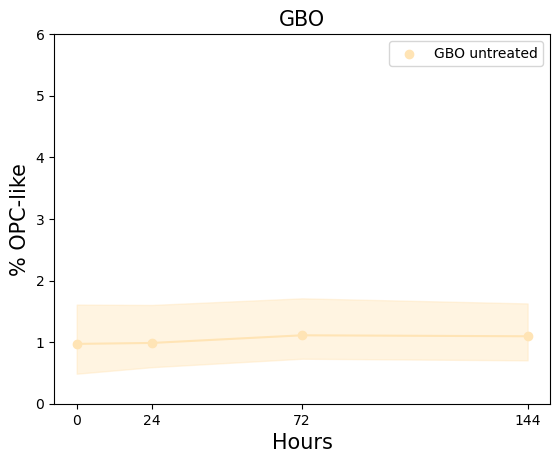

In [13]:
numb = merg1.index.astype(int)
plt.scatter(numb, merg1,label='GBO untreated', color='moccasin')
plt.plot(numb, merg1, color='moccasin')
plt.fill_between(numb, np.min(merg[0:3]),np.max(merg[0:3]), color='moccasin', alpha=0.4)
plt.ylim(0, 6)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% OPC-like', fontsize=15)
plt.title('GBO', fontsize=15)
plt.xticks(numb)
threshold1 = 0.2
threshold2 = 71
tr = numb +3

In [14]:
df = GBO.to_df(layer=None) #Save as dataframe
df_all = df.sum(axis=1) #total UMIs per sample
NPC_df = df[NPC] # NPC-genes dataframe
df_NPC = NPC_df.sum(axis=1) #total UMIs NPC genes per sample
zero = GBO[GBO.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_NPC = df_NPC[zero.obs.index]
one = GBO[GBO.obs["Time"] == "24h"]
one_all = df_all[one.obs.index]
one_NPC = df_NPC[one.obs.index]
three = GBO[GBO.obs["Time"] == "72h"]
three_all = df_all[three.obs.index]
three_NPC = df_NPC[three.obs.index]
six = GBO[GBO.obs["Time"] == "144h"]
six_all = df_all[six.obs.index]
six_NPC = df_NPC[six.obs.index]
#Fraction of NPC-genes UMIs of total per timepoint 
NPC_zero = zero_NPC/zero_all
NPC_one = one_NPC/one_all
NPC_three = three_NPC/three_all
NPC_six = six_NPC/six_all
#Make a dataframe with timepoint as columns
merged = pd.concat([NPC_zero, NPC_one, NPC_three, NPC_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(GBO.obs.Time_Sample)
merged1 = merged.rename(index=rename) #rename index 
merged1 = merged1.multiply(100) #multiply by 100 (display percent)
rename = dict(GBO.obs.Sample)
merg = merged.rename(index=rename)
merg = merg.mean(level=0) #condense df by merging rows of same sample+condition but different time points
merg = merg.multiply(100)
merg1 = merg.mean(axis=0) #condense df by merging all samples (mean) of same condition but different time points (columns) 
merg

,0,24,72,144
SL007,2.192169,2.197327,2.345403,2.087749
SL013,1.466083,1.736872,1.774208,1.804754
SL014,0.840836,1.019334,1.037157,1.053616
SL027A,1.209941,1.413591,1.298830,1.301273


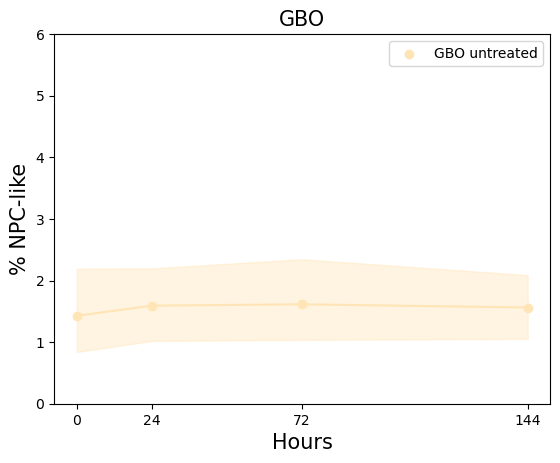

In [15]:
numb = merg1.index.astype(int)
plt.scatter(numb, merg1,label='GBO untreated', color='moccasin')
plt.plot(numb, merg1, color='moccasin')
plt.fill_between(numb, np.min(merg[0:3]),np.max(merg[0:3]), color='moccasin', alpha=0.4)
plt.ylim(0, 6)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% NPC-like', fontsize=15)
plt.title('GBO', fontsize=15)
plt.xticks(numb)
threshold1 = 0.2
threshold2 = 71
tr = numb +3

In [16]:
df = GBO.to_df(layer=None) #Save as dataframe
df_all = df.sum(axis=1) #total UMIs per sample
MES_df = df[AC] # AC-genes dataframe
df_mes = MES_df.sum(axis=1) #total UMIs AC genes per sample
zero = GBO[GBO.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_mes = df_mes[zero.obs.index]
one = GBO[GBO.obs["Time"] == "24h"]
one_all = df_all[one.obs.index]
one_mes = df_mes[one.obs.index]
three = GBO[GBO.obs["Time"] == "72h"]
three_all = df_all[three.obs.index]
three_mes = df_mes[three.obs.index]
six = GBO[GBO.obs["Time"] == "144h"]
six_all = df_all[six.obs.index]
six_mes = df_mes[six.obs.index]
#Fraction of AC-genes UMIs of total per timepoint 
MES_zero = zero_mes/zero_all
MES_one = one_mes/one_all
MES_three = three_mes/three_all
MES_six = six_mes/six_all
#Make a dataframe with timepoint as columns
merged = pd.concat([MES_zero, MES_one, MES_three, MES_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(GBO.obs.Time_Sample)
merged1 = merged.rename(index=rename) #rename index 
merged1 = merged1.multiply(100) #multiply by 100 (display percent)
rename = dict(GBO.obs.Sample)
merg = merged.rename(index=rename)
merg = merg.mean(level=0) #condense df by merging rows of same sample+condition but different time points
merg = merg.multiply(100)
merg1 = merg.mean(axis=0) #condense df by merging all samples (mean) of same condition but different time points (columns) 
merg

,0,24,72,144
SL007,5.253101,4.968283,4.196188,4.615681
SL013,1.131346,0.818558,1.096786,0.958497
SL014,3.556216,3.639995,4.194310,3.871093
SL027A,3.269437,3.428914,2.851513,3.218930


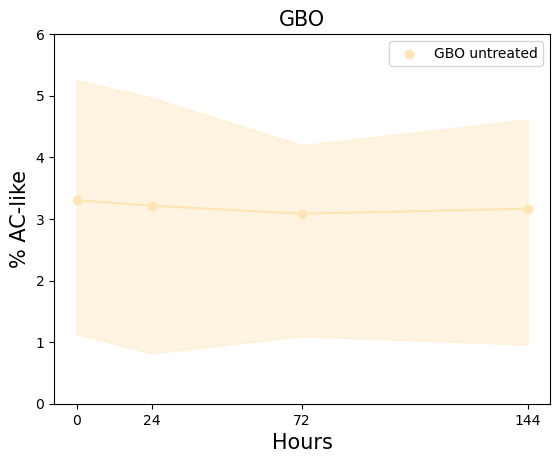

In [17]:
numb = merg1.index.astype(int)
plt.scatter(numb, merg1,label='GBO untreated', color='moccasin')
plt.plot(numb, merg1, color='moccasin')
plt.fill_between(numb, np.min(merg[0:3]),np.max(merg[0:3]), color='moccasin', alpha=0.4)
plt.ylim(0, 6)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% AC-like', fontsize=15)
plt.title('GBO', fontsize=15)
plt.xticks(numb)
None